# Week 4 Day 2 Lab


In [8]:
import numpy as np
import pandas as pd
import statistics as stats
import matplotlib.pyplot as plt
from ipywidgets import interact, Text, FloatSlider
from IPython.display import display
from scipy.stats import beta, norm
from scipy import stats

### Problem 1: Random Data Set
1. Generate a data set of size 300 using `np.random` 
2. Save this data set as a pandas dataframe
3. Download the dataset as a csv using `dataframe_name.to_csv("file_name.csv", index=False)`

In [9]:
data = np.random.uniform(0,10,300)

In [10]:
print(np.random.uniform(0,10,300))

[5.14189142 9.78384888 8.54298438 7.47315935 8.60717174 2.60326301
 5.64622176 2.57718254 7.26736121 1.17955237 0.70770589 7.04202571
 6.81016014 3.88181389 0.09454938 6.93573618 4.94901679 3.89930302
 0.90749889 2.05034343 6.41174559 2.80463558 1.52230355 6.26198878
 0.97239462 1.15487916 4.09445938 2.8470398  4.28839557 5.3919196
 5.40827346 5.32891197 7.5618788  1.79095595 8.34788095 5.59275638
 7.93095971 5.47412966 7.72822998 7.32456884 4.99440757 8.45572219
 1.22892459 5.23139176 4.94324484 8.94881449 9.71523071 4.1200063
 8.7525096  5.35216882 4.7515926  6.37407729 3.98077168 7.67745347
 7.26822608 1.60785442 8.35960049 2.14213962 4.42041183 0.2203386
 8.55818294 0.70261856 8.81328403 4.35028145 7.93579035 5.77177253
 4.52234671 4.85781723 5.48789676 2.69887782 4.78498884 8.55251152
 7.05458622 9.71598277 8.62859156 1.51088471 7.0192361  4.20315893
 5.66602389 8.12926322 4.3072678  3.02158255 5.55357219 4.73492723
 3.51663012 1.05406116 4.78794171 3.47607434 7.66023646 3.8384926

In [11]:
df = pd.DataFrame(data, columns=['random'])

In [12]:
df.to_csv("random.csv", index = False)

### Problem 2: Measures of Centrality
There are many ways to calculate what a data set is centered around. A few examples you have seen:

- Mean - The average of a dataset ($\bar{x}=\frac{1}{n}\sum\limits_{i=1}^nx_i$ for data points $x_i$)
- Median - The "middle data point" (average of 2 middle data points if data size is even-sized)
- Mode - The most common value (value with most number of occurences in data set)


1. Write your own function that calculate each of these.
2. Read the csv from Problem 1 into your notebook using `pd.read_csv("file_name.csv")`
3. Plot a histogram of the data and use `plt.axvline()` to plot vertical lines for the mean, median, and mode on the same histogram. 
4. Do you notice anything about the mean, median, and mode? How can you explain this behavior?

In [37]:
#1
x = [1,2,3,3,5]
np.mean(x)

np.float64(2.8)

In [38]:
np.median(x)

np.float64(3.0)

In [82]:
stats.mode(x)

ModeResult(mode=np.int64(3), count=np.int64(2))

This is just to see how these work. Next is my actual responses for question 1.

In [97]:
def mean(data):
    total=0
    for value in data:
        total+=value
    return total/len(data)

In [98]:
data =[1,2,3,4,5]
print(mean(data))

3.0


In [99]:
#2
pd.read_csv("random.csv")

,random
0,7.312345
1,2.963655
2,7.421074
3,7.118164
4,2.085189
...,...
295,9.994297
296,4.084058
297,2.651789
298,2.022025


In [100]:
#3
mean = np.mean(df)
print (mean)

4.983275417095486


In [49]:
median = np.median(df)
print (median)

4.831923704953992


In [71]:
mode = stats.mode(df)
print (mode[0])


[0.0195001]


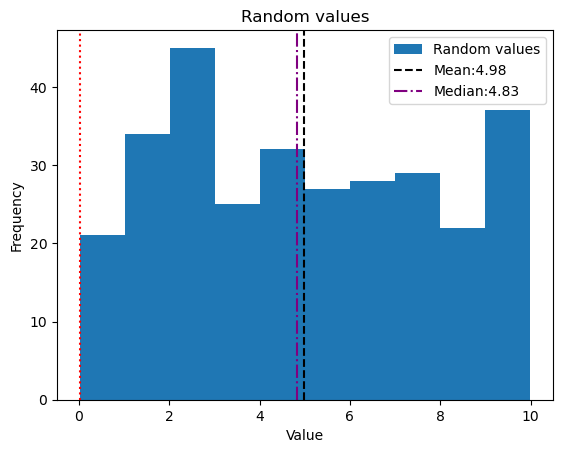

In [86]:
plt.hist(df["random"], label="Random values")
plt.axvline(mean,linestyle="--",color="black",label=f"Mean:{mean:.2f}")
plt.axvline(median,linestyle="-.",color="purple",label=f"Median:{median:.2f}")
plt.axvline(mode[0],linestyle=":",color="red")
plt.title("Random values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Problem 3: Measures of Variability
We don't care solely where the data is centered, but also how spread out the data is around that center. Some ways we can measure this:
- Mean Absolute Deviation - Average of distance to the mean ($MAD(x)= \frac{1}{n}\sum\limits_{i=1}^n|x_i-\bar{x}|$)
- Variance - Average squared distance to the mean ($Var(x)=\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2$)
- Standard Deviation - Square root of average squared distance to the mean ($s(x)=\sqrt{\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2}$)

where $x$ is the entire dataset, $x_i$ is a data point, and $\bar{x}$ is the mean of the dataset.

1. Write your own function that calculate each of these.
2. Plot a histogram of the data and use `plt.axvline(mean + variance)` and `plt.axvline(mean-variance)` to plot vertical lines for variance on the same histogram. Do the same with adding and subtracting mean absolute deviation and standard deviation.
3. Do you notice anything about lines corresponding to the different definitions variability? How can you explain this behavior?